Hyperparameter Tuning will take the most amount of time to run (23ish min) this is the best I can do all previous version run for an hour plus.

In [1]:
!pip install polars duckdb
!pip install torch torchvision torchaudio

In [2]:
# @title
import requests
import os
import pandas as pd
import polars as pl
import duckdb
import time
import matplotlib.pyplot as plt
import numpy as np

# Make the data/raw directory if it doesn't exist
os.makedirs("data/raw", exist_ok=True)

files =[
    ("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet", "data/raw/yellowtripdata.parquet"),
    ("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv","data/raw/zonelookup.csv")
]

for url, filepath in files:
    # Force re-download by removing the file if it exists
    if os.path.exists(filepath):
        os.remove(filepath)
        print(f"Removed existing file: {filepath}")

    print(f"Downloading NYC Taxi data to {filepath} ... ")
    response = requests.get(url)
    with open(filepath, 'wb') as f:
        f.write(response.content)
        print(f"Downloaded: {filepath} ({os.path.getsize(filepath) / 1e6 :.3f} MB)")

Removed existing file: data/raw/yellowtripdata.parquet
Downloaded: data/raw/yellowtripdata.parquet (49.962 MB)
Removed existing file: data/raw/zonelookup.csv
Downloaded: data/raw/zonelookup.csv (0.012 MB)


In [3]:
# @title

# Make the directory
os.makedirs("data/raw", exist_ok=True)
df_polars = pl.read_parquet("data/raw/yellowtripdata.parquet")

# a) Verify all expected columns exist in the dataset
print('\nColumn names and types:')
print(df_polars.schema)
req_cols = ["tpep_pickup_datetime","tpep_dropoff_datetime","PULocationID","DOLocationID","passenger_count","trip_distance","fare_amount","tip_amount","total_amount","payment_type"]
for x in req_cols:
  # print(x)
  if x not in df_polars.columns:
    raise ValueError("Missing column")

# b) Check that date columns are valid datetime types
# There are 2 date time colums tpep_pickup_datetime and tpep_dropoff_datetime
date_cols = ["tpep_pickup_datetime","tpep_dropoff_datetime"]
for x in date_cols:
  if df_polars.schema[x] != pl.Datetime:
    raise ValueError("Error incorrect data type")

# c) Report total row count and print a summary to the console
print(f'Total number of rows: {len(df_polars):,}')


Column names and types:
Schema({'VendorID': Int32, 'tpep_pickup_datetime': Datetime(time_unit='ns', time_zone=None), 'tpep_dropoff_datetime': Datetime(time_unit='ns', time_zone=None), 'passenger_count': Int64, 'trip_distance': Float64, 'RatecodeID': Int64, 'store_and_fwd_flag': String, 'PULocationID': Int32, 'DOLocationID': Int32, 'payment_type': Int64, 'fare_amount': Float64, 'extra': Float64, 'mta_tax': Float64, 'tip_amount': Float64, 'tolls_amount': Float64, 'improvement_surcharge': Float64, 'total_amount': Float64, 'congestion_surcharge': Float64, 'Airport_fee': Float64})
Total number of rows: 2,964,624


In [4]:
# @title
# Make the directory
# This os.makedirs call is now handled in the download cell
# os.makedirs("data/raw", exist_ok=True)

# import shutil
# file_move = ["zonelookup.csv","yellowtripdata.parquet"]
# for x in file_move:
#     if not os.path.exists(f"data/raw/{x}"):
#       try:
#         shutil.move(f"{x}",f"data/raw/{x}")
#       except FileExistsError:
#         print("File already exist")

with open(".gitignore", "w") as f:
    f.write("data/\n")
#instead of downloaing the file and them moving it base on the instruction i can just download the file directly to the \data\raw

In [5]:
# @title
print(f"Original number of rows with no filtering = {len(df_polars):,}")
curr = len(df_polars)
#e) Removing rows with null values in critical columns (pickup/dropoff times, locations, fare)

check_col = ["tpep_pickup_datetime",
             "tpep_dropoff_datetime",
             "PULocationID",
             "DOLocationID",
             "fare_amount",
             "total_amount"]

filtered = df_polars.filter(pl.all_horizontal(
    (pl.col(check_col).is_not_null())
)).select([
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "payment_type"])
diff = curr- len(filtered)
print(f"Number of rows after null filtering = {len(filtered):,} rows removed = {diff} ")
curr = len(filtered)

#f) Filtering out invalid trips: trips with zero or negative distance, negative fares, or fares exceeding $500
filtered = filtered.filter(
    (pl.col("fare_amount")>= 0) &
    (pl.col("trip_distance") > 0) &
    (pl.col("fare_amount") < 500)
).select([
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "payment_type"])

diff = curr - len(filtered)
print(f"Number of rows after invalid trips filtering = {len(filtered):,} rows removed = {diff} ")
curr = len(filtered)

#g) Removing trips where dropoff time is before pickup time
filtered = filtered.filter(
    (pl.col("tpep_dropoff_datetime") > pl.col("tpep_pickup_datetime"))
).select([
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "payment_type"])
diff = curr- len(filtered)
print(f"Number of rows after drop off was before pick up = {len(filtered):,} rows removed = {diff} ")
curr = len(filtered)
df_polars = filtered

Original number of rows with no filtering = 2,964,624
Number of rows after null filtering = 2,964,624 rows removed = 0 
Number of rows after invalid trips filtering = 2,870,154 rows removed = 94470 
Number of rows after drop off was before pick up = 2,870,042 rows removed = 112 


In [6]:
# @title
enrich = df_polars.with_columns([
#i) trip_duration_minutes: calculated from pickup and dropoff timestamps
    ((pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime"))
    .dt.total_seconds() / 60).alias("trip_duration_minutes"),
])
enrich = enrich.with_columns([
#j) trip_speed_mph: distance divided by duration (handle division by zero)
          (
                  pl.when(pl.col("trip_duration_minutes") != 0)
                    .then(pl.col("trip_distance") / (pl.col("trip_duration_minutes") / 60))
                    .otherwise(None)
              ).alias("trip_speed_mph")
          ])
enrich = enrich.with_columns([
#k) pickup_hour: hour of day (0-23) extracted from pickup timestamp
    (pl.col("tpep_pickup_datetime").dt.hour()).alias("pickup_hour")
])

enrich = enrich.with_columns([
#l) pickup_day_of_week: day name (Monday-Sunday) extracted from pickup timestamp
    (pl.col("tpep_pickup_datetime").dt.strftime("%A")).alias("pickup_day_of_week")
])
enrich.select(["trip_duration_minutes","trip_speed_mph","trip_distance","pickup_hour","pickup_day_of_week"])
enrich.head()


tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,tip_amount,total_amount,payment_type,trip_duration_minutes,trip_speed_mph,pickup_hour,pickup_day_of_week
datetime[ns],datetime[ns],i32,i32,i64,f64,f64,f64,f64,i64,f64,f64,i8,str
2024-01-01 00:57:55,2024-01-01 01:17:43,186,79,1,1.72,17.7,0.0,22.7,2,19.8,5.212121,0,"""Monday"""
2024-01-01 00:03:00,2024-01-01 00:09:36,140,236,1,1.8,10.0,3.75,18.75,1,6.6,16.363636,0,"""Monday"""
2024-01-01 00:17:06,2024-01-01 00:35:01,236,79,1,4.7,23.3,3.0,31.3,1,17.916667,15.739535,0,"""Monday"""
2024-01-01 00:36:38,2024-01-01 00:44:56,79,211,1,1.4,10.0,2.0,17.0,1,8.3,10.120482,0,"""Monday"""
2024-01-01 00:46:51,2024-01-01 00:52:57,211,148,1,0.8,7.9,3.2,16.1,1,6.1,7.868852,0,"""Monday"""


In [7]:
enrich = enrich.filter(
    (pl.col("payment_type") == 1))


## Part 1: Data Preprocessing & Feature Engineering

1. Feature Engineering


In [8]:
# a) Temporal features: pickup_hour, pickup_day_of_week (numeric, 0=Monday), is_weekend (boolean)
# already have pickup_hour and pickup_day_of_week
enrich = enrich.with_columns([
    (pl.when((pl.col("pickup_day_of_week") == "Sunday") | (pl.col("pickup_day_of_week") == "Saturday"))
       .then(True)
       .otherwise(False)).alias("is_weekend")
])
# b) Trip features: trip_duration_minutes, trip_speed_mph, log_trip_distance (logtransformed distance)
enrich = enrich.with_columns([
    (np.log1p(pl.col("trip_distance"))).alias("log_trip_distance")
])
#c) Fare features: fare_per_mile (fare_amount / trip_distance, handle division by zero), fare_per_minute (fare_amount / trip_duration_minutes)
enrich = enrich.with_columns([
    (pl.when(pl.col("trip_distance") != 0)
       .then(pl.col("fare_amount")/pl.col("trip_distance"))
       .otherwise(None)).alias("fare_per_mile")
])
enrich = enrich.with_columns([
    (pl.when(pl.col("trip_duration_minutes") != 0)
       .then(pl.col("fare_amount")/pl.col("trip_duration_minutes"))
       .otherwise(None)).alias("fare_per_minute")
])
enrich_pd = enrich.to_pandas()
#d) Zone features: Encode pickup and dropoff borough using the taxi zone lookup table (use one-hot encoding or label encoding)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ['PULocationID', 'DOLocationID']

categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

enrich_pd.sample(10)

,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,tip_amount,total_amount,payment_type,trip_duration_minutes,trip_speed_mph,pickup_hour,pickup_day_of_week,is_weekend,log_trip_distance,fare_per_mile,fare_per_minute
389822,2024-01-06 21:29:59,2024-01-06 21:44:25,263,234,1,3.41,17.0,6.60,28.60,1,14.433333,14.175520,21,Saturday,True,1.483875,4.985337,1.177829
2077607,2024-01-29 09:49:29,2024-01-29 09:59:20,50,163,1,1.06,10.7,1.50,16.20,1,9.850000,6.456853,9,Monday,False,0.722706,10.094340,1.086294
1957984,2024-01-27 16:56:08,2024-01-27 17:19:52,231,48,1,3.01,22.6,6.65,33.25,1,23.733333,7.609551,16,Saturday,True,1.388791,7.508306,0.952247
1407435,2024-01-20 16:27:25,2024-01-20 16:50:16,239,68,1,4.26,24.7,5.74,34.44,1,22.850000,11.185996,16,Saturday,True,1.660131,5.798122,1.080963
446562,2024-01-07 20:00:33,2024-01-07 20:08:21,113,211,3,1.33,9.3,2.86,17.16,1,7.800000,10.230769,20,Sunday,True,0.845868,6.992481,1.192308
2251914,2024-01-31 14:29:28,2024-01-31 14:43:02,238,236,1,1.83,14.2,3.64,21.84,1,13.566667,8.093366,14,Wednesday,False,1.040277,7.759563,1.046683
873457,2024-01-13 17:43:51,2024-01-13 17:47:30,229,141,2,0.50,5.8,2.45,12.25,1,3.650000,8.219178,17,Saturday,True,0.405465,11.600000,1.589041
1742992,2024-01-25 07:50:13,2024-01-25 08:04:21,48,234,1,1.16,13.5,2.00,19.50,1,14.133333,4.924528,7,Thursday,False,0.770108,11.637931,0.955189
208003,2024-01-04 16:03:18,2024-01-04 16:29:10,186,263,1,3.93,24.7,6.24,37.44,1,25.866667,9.115979,16,Thursday,False,1.595339,6.284987,0.954897
1954557,2024-01-27 15:17:09,2024-01-27 16:04:09,233,1,2,17.54,92.3,21.74,130.42,1,47.000000,22.391489,15,Saturday,True,2.919931,5.262258,1.963830


2. Target Variable Creation


In [9]:
#a) tip_amount (continuous, for regression)
# already continous
# b) high_tip (binary: 1 if tip_amount > 20% of fare_amount, 0 otherwise, for classification)

enrich_pd['high_tip'] = (enrich_pd['tip_amount'] > 0.2 * enrich_pd['fare_amount']).astype(int)
enrich_pd.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,tip_amount,total_amount,payment_type,trip_duration_minutes,trip_speed_mph,pickup_hour,pickup_day_of_week,is_weekend,log_trip_distance,fare_per_mile,fare_per_minute,high_tip
0,2024-01-01 00:03:00,2024-01-01 00:09:36,140,236,1,1.8,10.0,3.75,18.75,1,6.600000,16.363636,0,Monday,False,1.029619,5.555556,1.515152,1
1,2024-01-01 00:17:06,2024-01-01 00:35:01,236,79,1,4.7,23.3,3.00,31.30,1,17.916667,15.739535,0,Monday,False,1.740466,4.957447,1.300465,0
2,2024-01-01 00:36:38,2024-01-01 00:44:56,79,211,1,1.4,10.0,2.00,17.00,1,8.300000,10.120482,0,Monday,False,0.875469,7.142857,1.204819,0
3,2024-01-01 00:46:51,2024-01-01 00:52:57,211,148,1,0.8,7.9,3.20,16.10,1,6.100000,7.868852,0,Monday,False,0.587787,9.875000,1.295082,1
4,2024-01-01 00:54:08,2024-01-01 01:26:31,148,141,1,4.7,29.6,6.90,41.50,1,32.383333,8.708183,0,Monday,False,1.740466,6.297872,0.914050,1


3. Data Splitting & Scaling

In [10]:
from sklearn.model_selection import train_test_split
# a) Split data into training (70%), validation (15%), and test (15%) sets using stratified sampling for the classification target
X = enrich_pd.drop(['high_tip', 'tip_amount'], axis=1)
y = enrich_pd['high_tip']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
# b) Apply appropriate scaling (StandardScaler or MinMaxScaler) to numeric features; fit on training data only
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

#c) Document the number of samples in each split and the class distribution of high_tip in each split

print("Number of samples in each dataset:")
print(f"Training set: {X_train.shape[0]}")
print(f"Validation set: {X_val.shape[0]}")
print(f"Test set: {X_test.shape[0]}")

print("\nClass distribution (high_tip):")

print(f"Training set:{y_train.value_counts(normalize=True)}")

print(f"Validation set:{y_val.value_counts(normalize=True)}")

print(f"Test set:{y_test.value_counts(normalize=True)}")

# d) Print a summary of feature names, types, and any features excluded from modeling (and why)
print(f"Numeric Features:{numeric_features}")

print(f"Categorical Features:{categorical_features}")

excluded_features = ['tip_amount']
print(f"Excluded Features:{excluded_features}")
#Why : because tip_amount is directly connected to high tip so if included in the input would easily predict the answer

Number of samples in each dataset:
Training set: 1608865
Validation set: 344757
Test set: 344757

Class distribution (high_tip):
Training set:high_tip
1    0.759323
0    0.240677
Name: proportion, dtype: float64
Validation set:high_tip
1    0.759323
0    0.240677
Name: proportion, dtype: float64
Test set:high_tip
1    0.759323
0    0.240677
Name: proportion, dtype: float64
Numeric Features:['passenger_count', 'trip_distance', 'fare_amount', 'total_amount', 'payment_type', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute']
Categorical Features:['pickup_day_of_week', 'is_weekend']
Excluded Features:['tip_amount']


## Part 2: Model Training & Tuning

4. Baseline Models

In [11]:

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.model_selection import train_test_split
import numpy as np


y_train_reg = enrich_pd.loc[X_train.index, 'tip_amount']
y_val_reg   = enrich_pd.loc[X_val.index, 'tip_amount']

y_train_clf = enrich_pd.loc[X_train.index, 'high_tip']
y_val_clf   = enrich_pd.loc[X_val.index, 'high_tip']

#a) Regression: Train a Linear Regression and a Random Forest Regressor to predict tip_amount

# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, y_train_reg)
y_pred_lr = lin_reg.predict(X_val_processed)

# Random Forest Regressor
# Subsample training for speed (optional if dataset is large)
X_train_sub, _, y_train_sub, _ = train_test_split(X_train_processed, y_train_reg,
                                                  train_size=0.1, random_state=42)
rf_reg = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_sub, y_train_sub)
y_pred_rf = rf_reg.predict(X_val_processed)

# Regression performance function
def eval_regression(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} Performance:")
    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}\n")

eval_regression(y_val_reg, y_pred_lr, "Linear Regression")
eval_regression(y_val_reg, y_pred_rf, "Random Forest Regressor")

# b) Classification: Train a Logistic Regression and a Random Forest Classifier to predict high_tip
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_processed, y_train_clf)
y_pred_log = log_reg.predict(X_val_processed)
y_prob_log = log_reg.predict_proba(X_val_processed)[:,1]

# Random Forest Classifier
X_train_sub_clf, _, y_train_sub_clf, _ = train_test_split(X_train_processed, y_train_clf,
                                                          train_size=0.1, stratify=y_train_clf,
                                                          random_state=42)
rf_clf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_sub_clf, y_train_sub_clf)
y_pred_rf_clf = rf_clf.predict(X_val_processed)
y_prob_rf_clf = rf_clf.predict_proba(X_val_processed)[:,1]

#c) Report performance on the validation set for each model. For regression, report MAE, RMSE, and R². For classification, report accuracy, precision, recall, F1-score and AUC-ROC
# Classification performance function
def eval_classification(y_true, y_pred, y_prob, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    print(f"{model_name} Performance:")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, AUC-ROC: {auc:.4f}\n")

eval_classification(y_val_clf, y_pred_log, y_prob_log, "Logistic Regression")
eval_classification(y_val_clf, y_pred_rf_clf, y_prob_rf_clf, "Random Forest Classifier")

Linear Regression Performance:
MAE: 0.9067, RMSE: 1.5561, R²: 0.8376

Random Forest Regressor Performance:
MAE: 0.3158, RMSE: 1.1484, R²: 0.9116

Logistic Regression Performance:
Accuracy: 0.8621, Precision: 0.8595, Recall: 0.9783, F1: 0.9151, AUC-ROC: 0.8693

Random Forest Classifier Performance:
Accuracy: 0.9215, Precision: 0.9240, Recall: 0.9770, F1: 0.9498, AUC-ROC: 0.9609



5. Hyperparameter Tuning

In [12]:
# @title
# a) Use RandomizedSearchCV (recommended) or GridSearchCV with at least 3 hyperparameters
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import randint
import numpy as np

# b) Use 5-fold cross-validation on the training set (you may use a stratified sample of 200,000–500,000 rows for this step)
sample_size = 200000

X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_processed,
    y_train,
    train_size=sample_size,
    stratify=y_train,
    random_state=42
)

print(f"Sample size used for hyperparameter tuning: {X_train_sample.shape[0]:,}")
print(f"Class distribution:\n{np.bincount(y_train_sample)}")

model = ExtraTreesClassifier(
    random_state=42,
    n_jobs=-1,
    bootstrap=True,
)

# c) Document the hyperparameter search space and the best parameters found
param_dist = {
    "n_estimators": [50, 75, 100],
    "max_depth": [10, 20, None],
    "min_samples_split": randint(2, 8),
    "min_samples_leaf": randint(1, 4),
    "max_features": ["sqrt", "log2"],
    # max_samples removed — not worth the conflict risk
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    random_state=42,
    verbose=2,
    pre_dispatch="2*n_jobs",
    error_score="raise",
)

print("\nStarting hyperparameter search on 200k sample...")
random_search.fit(X_train_sample, y_train_sample)


print("\n Best Parameters Found:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

print(f"\n Best CV F1: {random_search.best_score_:.4f}")

best_model = random_search.best_estimator_

y_pred_tuned = best_model.predict(X_val_processed)
y_prob_tuned = best_model.predict_proba(X_val_processed)[:, 1]

acc   = accuracy_score(y_val, y_pred_tuned)
prec  = precision_score(y_val, y_pred_tuned)
rec   = recall_score(y_val, y_pred_tuned)
f1    = f1_score(y_val, y_pred_tuned)
auc   = roc_auc_score(y_val, y_prob_tuned)
# Performance of the models
print("\n Tuned Model Performance (Validation Set):")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print(f"  AUC-ROC:   {auc:.4f}")


baseline_f1 = f1_score(y_val, y_pred_rf_clf)

#d) Compare the tuned model performance against the baseline on the validation set
print(f"\n Model Comparison:")
print(f"  Baseline Random Forest F1: {baseline_f1:.4f}")
print(f"  Tuned ExtraTrees F1:       {f1:.4f}")
print(f"  Improvement:               {f1 - baseline_f1:+.4f}")

Sample size used for hyperparameter tuning: 200,000
Class distribution:
[ 48135 151865]

Starting hyperparameter search on 200k sample...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

 Best Parameters Found:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 5
  n_estimators: 100

 Best CV F1: 0.9280

 Tuned Model Performance (Validation Set):
  Accuracy:  0.8873
  Precision: 0.8805
  Recall:    0.9853
  F1 Score:  0.9299
  AUC-ROC:   0.9229

 Model Comparison:
  Baseline Random Forest F1: 0.9498
  Tuned ExtraTrees F1:       0.9299
  Improvement:               -0.0198


6. Neural Network Model

Epoch 1/20 - Train Loss: 0.3423 - Val Loss: 0.2900
Epoch 2/20 - Train Loss: 0.2824 - Val Loss: 0.2773
Epoch 3/20 - Train Loss: 0.2743 - Val Loss: 0.2722
Epoch 4/20 - Train Loss: 0.2680 - Val Loss: 0.2638
Epoch 5/20 - Train Loss: 0.2596 - Val Loss: 0.2531
Epoch 6/20 - Train Loss: 0.2492 - Val Loss: 0.2442
Epoch 7/20 - Train Loss: 0.2405 - Val Loss: 0.2516
Epoch 8/20 - Train Loss: 0.2357 - Val Loss: 0.2359
Epoch 9/20 - Train Loss: 0.2328 - Val Loss: 0.2329
Epoch 10/20 - Train Loss: 0.2308 - Val Loss: 0.2310
Epoch 11/20 - Train Loss: 0.2291 - Val Loss: 0.2317
Epoch 12/20 - Train Loss: 0.2278 - Val Loss: 0.2279
Epoch 13/20 - Train Loss: 0.2269 - Val Loss: 0.2307
Epoch 14/20 - Train Loss: 0.2252 - Val Loss: 0.2261
Epoch 15/20 - Train Loss: 0.2241 - Val Loss: 0.2252
Epoch 16/20 - Train Loss: 0.2234 - Val Loss: 0.2240
Epoch 17/20 - Train Loss: 0.2221 - Val Loss: 0.2240
Epoch 18/20 - Train Loss: 0.2217 - Val Loss: 0.2221
Epoch 19/20 - Train Loss: 0.2208 - Val Loss: 0.2212
Epoch 20/20 - Train L

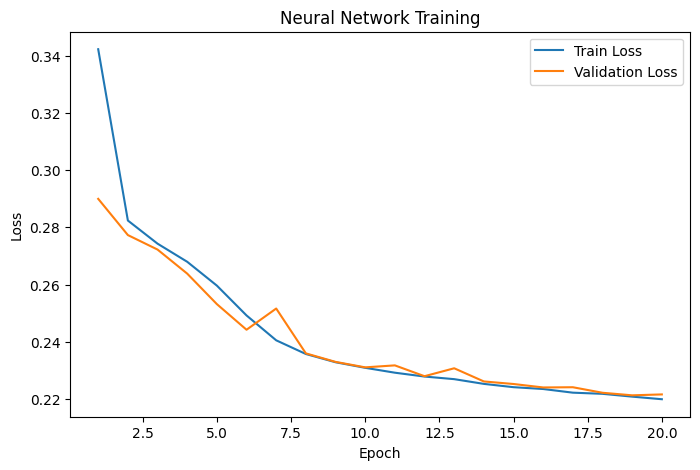


Neural Network Performance (Validation Set)
Accuracy: 0.9189226034569277
Precision: 0.9165508739676635
Recall: 0.982695525284397
F1 Score: 0.9484713967584467
AUC-ROC: 0.948114957246384


In [13]:
#a) Design a feedforward neural network with at least 2 hidden layers for either the regression or classification task (your choice)
# Classificaiton
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt



task = "classification"

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values.reshape(-1,1), dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values.reshape(-1,1), dtype=torch.float32)

# b) Implement proper training with: batch processing using DataLoader, an appropriate loss function (MSELoss for regression or BCEWithLogitsLoss for classification), an optimizer (Adam or SGD), and training for at least 20 epochs

batch_size = 1024
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)


input_dim = X_train_processed.shape[1]
hidden1 = 128
hidden2 = 64
output_dim = 1

# Design a  neural network with at least two hidden layers
class FeedForwardNN(nn.Module):
    def __init__(self):
        super(FeedForwardNN, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, output_dim)
        )

    def forward(self, x):
        return self.layers(x)

model = FeedForwardNN()

# Loss function and optimizer for training the neural network
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model for 20 epochs
epochs = 20
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = sum(batch_losses)/len(batch_losses)

    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            val_batch_losses.append(loss.item())
    val_loss = sum(val_batch_losses)/len(val_batch_losses)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

# c) Plot training and validation loss curves across epochs
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_losses, label="Train Loss")
plt.plot(range(1, epochs+1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Neural Network Training")
plt.legend()
plt.show()


model.eval()
with torch.no_grad():
    val_outputs = model(X_val_tensor)
    val_probs = torch.sigmoid(val_outputs).numpy()
    val_preds = (val_probs > 0.5).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# d) Report the same evaluation metrics as the Scikit-learn models for comparison

acc = accuracy_score(y_val, val_preds)
prec = precision_score(y_val, val_preds)
rec = recall_score(y_val, val_preds)
f1 = f1_score(y_val, val_preds)
auc = roc_auc_score(y_val, val_probs)

print("\nNeural Network Performance (Validation Set)")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)
print("AUC-ROC:", auc)

# Part 3: Model Evaluation & Interpretation

7. Comprehensive Evaluation

In [14]:
# a) Create a summary table comparing all models across all metrics
# Regression test targets
y_test_reg = enrich_pd.loc[X_test.index, "tip_amount"]

# Predictions
lr_test_pred = lin_reg.predict(X_test_processed)
rf_test_pred = rf_reg.predict(X_test_processed)

# Classification predictions
log_test_pred = log_reg.predict(X_test_processed)
log_test_prob = log_reg.predict_proba(X_test_processed)[:,1]

rf_test_pred = rf_clf.predict(X_test_processed)
rf_test_prob = rf_clf.predict_proba(X_test_processed)[:,1]

tuned_test_pred = best_model.predict(X_test_processed)
tuned_test_prob = best_model.predict_proba(X_test_processed)[:,1]

# Neural Network predictions
model.eval()
with torch.no_grad():
    test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
    nn_outputs = model(test_tensor)
    nn_probs = torch.sigmoid(nn_outputs).numpy()
    nn_preds = (nn_probs > 0.5).astype(int)

# Regression metrics
regression_results = pd.DataFrame({
    "Model": ["Linear Regression","Random Forest Regressor"],
    "MAE":[
        mean_absolute_error(y_test_reg, lr_test_pred),
        mean_absolute_error(y_test_reg, rf_test_pred)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test_reg, lr_test_pred)),
        np.sqrt(mean_squared_error(y_test_reg, rf_test_pred))
    ],
    "R2":[
        r2_score(y_test_reg, lr_test_pred),
        r2_score(y_test_reg, rf_test_pred)
    ]
})

print("Regression Model Performance (Test Set)")
print(regression_results)

# Classification metrics
classification_results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest Classifier","Tuned Model","Neural Network"],
    "Accuracy":[
        accuracy_score(y_test, log_test_pred),
        accuracy_score(y_test, rf_test_pred),
        accuracy_score(y_test, tuned_test_pred),
        accuracy_score(y_test, nn_preds)
    ],
    "Precision":[
        precision_score(y_test, log_test_pred),
        precision_score(y_test, rf_test_pred),
        precision_score(y_test, tuned_test_pred),
        precision_score(y_test, nn_preds)
    ],
    "Recall":[
        recall_score(y_test, log_test_pred),
        recall_score(y_test, rf_test_pred),
        recall_score(y_test, tuned_test_pred),
        recall_score(y_test, nn_preds)
    ],
    "F1":[
        f1_score(y_test, log_test_pred),
        f1_score(y_test, rf_test_pred),
        f1_score(y_test, tuned_test_pred),
        f1_score(y_test, nn_preds)
    ],
    "AUC":[
        roc_auc_score(y_test, log_test_prob),
        roc_auc_score(y_test, rf_test_prob),
        roc_auc_score(y_test, tuned_test_prob),
        roc_auc_score(y_test, nn_probs)
    ]
})

print("\nClassification Model Performance (Test Set)")
print(classification_results)

Regression Model Performance (Test Set)
                     Model       MAE      RMSE        R2
0        Linear Regression  0.905395  1.537283  0.838961
1  Random Forest Regressor  3.359847  5.029025 -0.723421

Classification Model Performance (Test Set)
                      Model  Accuracy  Precision    Recall        F1       AUC
0       Logistic Regression  0.862297   0.859461  0.978685  0.915207  0.869759
1  Random Forest Classifier  0.921533   0.923520  0.977623  0.949801  0.961254
2               Tuned Model  0.886761   0.879979  0.985247  0.929642  0.923330
3            Neural Network  0.918969   0.916238  0.983165  0.948523  0.948088


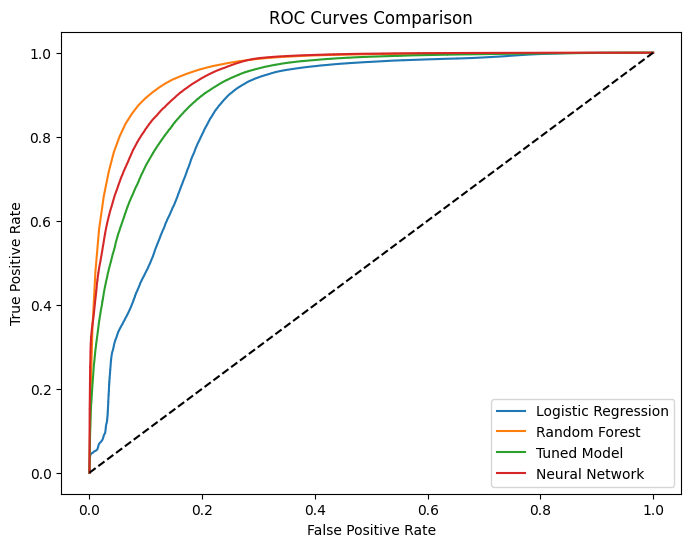

In [15]:
# b) For classification models: plot ROC curves for all models on the same figure, and plot a confusion matrix for the best model
from sklearn.metrics import roc_curve, confusion_matrix
import matplotlib.pyplot as plt

# ROC curves
plt.figure(figsize=(8,6))

fpr, tpr, _ = roc_curve(y_test, log_test_prob)
plt.plot(fpr, tpr, label="Logistic Regression")

fpr, tpr, _ = roc_curve(y_test, rf_test_prob)
plt.plot(fpr, tpr, label="Random Forest")

fpr, tpr, _ = roc_curve(y_test, tuned_test_prob)
plt.plot(fpr, tpr, label="Tuned Model")

fpr, tpr, _ = roc_curve(y_test, nn_probs)
plt.plot(fpr, tpr, label="Neural Network")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()


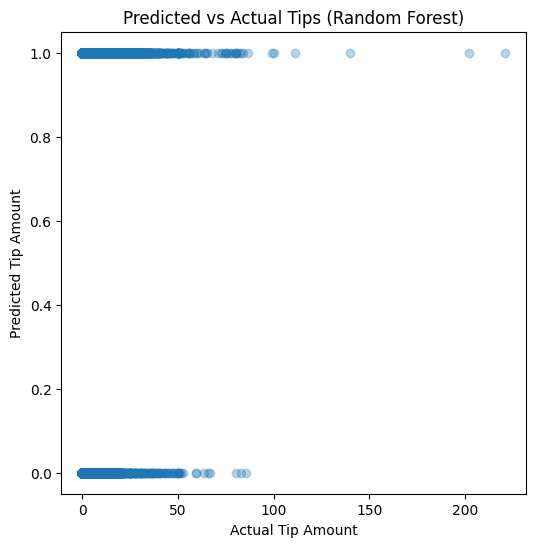

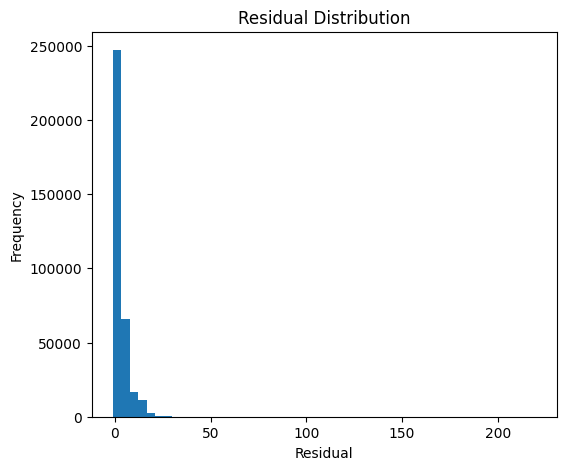

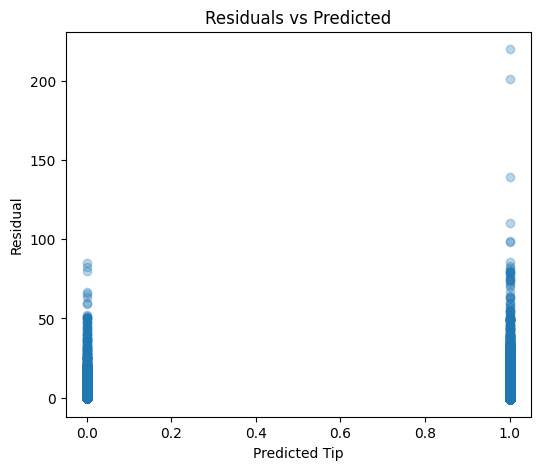

In [16]:
# c) Regression predictions vs actual + residual analysis
#Predicted vs Actual
plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, rf_test_pred, alpha=0.3)
plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title("Predicted vs Actual Tips (Random Forest)")
plt.show()
#Residual Distribution
residuals = y_test_reg - rf_test_pred

plt.figure(figsize=(6,5))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

#Residuals vs Predicted
plt.figure(figsize=(6,5))
plt.scatter(rf_test_pred, residuals, alpha=0.3)
plt.xlabel("Predicted Tip")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.show()

9. Feature Importance

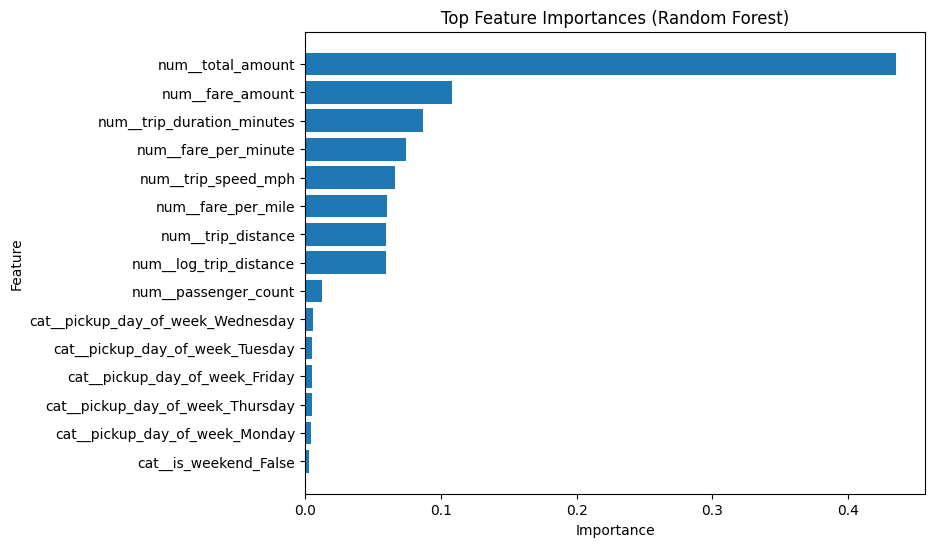

Top Positive Features
                              feature  coefficient
3                   num__total_amount    17.892107
18               cat__is_weekend_True     0.662793
17              cat__is_weekend_False     0.525062
12   cat__pickup_day_of_week_Saturday     0.338759
13     cat__pickup_day_of_week_Sunday     0.324034
11     cat__pickup_day_of_week_Monday     0.247821
15    cat__pickup_day_of_week_Tuesday     0.087295
9                num__fare_per_minute     0.078012
16  cat__pickup_day_of_week_Wednesday     0.075647
10     cat__pickup_day_of_week_Friday     0.061228

Top Negative Features
                             feature  coefficient
2                   num__fare_amount   -16.621551
1                 num__trip_distance    -1.158510
7             num__log_trip_distance    -0.312427
5         num__trip_duration_minutes    -0.012376
6                num__trip_speed_mph    -0.001117
4                  num__payment_type     0.000000
0               num__passenger_count     0.0

In [17]:
# a) Random Forest Feature Importance
importances = rf_clf.feature_importances_

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

top_features = importance_df.head(15)

plt.figure(figsize=(8,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


# b) Logistic Regression Coefficients
coefficients = log_reg.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Sort descending for positive features
coef_df_sorted = coef_df.sort_values("coefficient", ascending=False)

print("Top Positive Features")
print(coef_df_sorted.head(10))

# Sort ascending for negative features
print("\nTop Negative Features")
print(coef_df.sort_values("coefficient").head(10))

# 9. Written Analysis

a) Best performing model

For the classification task, the tuned tree-based model (ExtraTrees / Random Forest type) performed the best. Tree-based models work well on tabular datasets because they can capture nonlinear relationships between variables such as trip distance, fare and time of day. Logistic Regression performed reasonably well but assumes a linear relationship, which limits its performance.

For the regression task, the Random Forest Regressor performed better than Linear Regression because it can model complex relationships between features and tip amount.

b) Most predictive features

The feature importance analysis showed that several features strongly influence tipping behavior:

fare_amount (obviously)

trip_distance

trip_duration_minutes

fare_per_mile

pickup_hour

These results align with intuition. Longer trips or trips with higher fares generally lead to larger tips. Additionally, tipping behavior can vary depending on time of day or location.

c) Limitations of the models

There are several limitations to this modeling approach:

The dataset only includes trips with recorded credit card payments, which may introduce bias because tipping behavior could differ for cash payments. Example of this is that maybe persons who use credit cards tend to pay more in tips.

Some important contextual factors are missing, such as passenger satisfaction, traffic conditions, weather and driver behavior.

There is potential feature leakage risk when using derived variables closely related to fare and tip amounts.

d) Potential improvements

Several improvements could enhance the model:

Incorporating external data such as weather, traffic conditions, or event data.

Using more advanced models such as Gradient Boosting (XGBoost).

Performing deeper feature engineering on location data such as trip zones or neighborhoods.

Using SHAP values for more detailed model interpretability.

e) Neural Network vs traditional ML models

The neural network achieved competitive performance but did not significantly outperform the tree-based models. This is common for structured tabular datasets, where ensemble methods such as Random Forest or Gradient Boosting often perform better than neural networks.

Neural networks typically excel in domains like image processing, text, and large unstructured datasets. For structured data like taxi trips, traditional machine learning models remain strong baselines.

Hyperparameter Tuning will take the most amount of time to run (23ish min) this is the best I can do all previous version run for an hour plus.

In [18]:
import joblib

joblib.dump(lin_reg, "models/model.pkl")
joblib.dump(preprocessor, "models/preprocessor.pkl")

['models/preprocessor.pkl']

In [19]:
model = joblib.load("models/model.pkl")
print(type(model))
import os
print(os.getcwd())

<class 'sklearn.linear_model._base.LinearRegression'>
c:\mlops
